In [34]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


folder_offline_cc = Path.cwd().parents[1] / "optimized_feed" / "optimization_offline_cc"
for item in folder_offline_cc.iterdir():
    print(f"from {folder_offline_cc} : {item.name}")
    
folder_no_cc = Path.cwd().parents[1] / "optimized_feed" / "optimization_no_cc"
for item in folder_no_cc.iterdir():
    print(f"from {folder_no_cc} : {item.name}")

from c:\Users\spadmin\OneDrive - ETH Zurich\Documents\repos\linearized_milling_study\optimized_feed\optimization_offline_cc : Optimal_feed_curve.csv
from c:\Users\spadmin\OneDrive - ETH Zurich\Documents\repos\linearized_milling_study\optimized_feed\optimization_offline_cc : optimization_config.csv
from c:\Users\spadmin\OneDrive - ETH Zurich\Documents\repos\linearized_milling_study\optimized_feed\optimization_offline_cc : Optimization_output.jpg
from c:\Users\spadmin\OneDrive - ETH Zurich\Documents\repos\linearized_milling_study\optimized_feed\optimization_no_cc : Optimal_feed_curve.csv
from c:\Users\spadmin\OneDrive - ETH Zurich\Documents\repos\linearized_milling_study\optimized_feed\optimization_no_cc : optimization_config.csv
from c:\Users\spadmin\OneDrive - ETH Zurich\Documents\repos\linearized_milling_study\optimized_feed\optimization_no_cc : Optimization_output.jpg


In [ ]:
df_offline_cc = pd.read_csv(folder_offline_cc / "Optimal_feed_curve.csv")
df_no_cc = pd.read_csv(folder_no_cc / "Optimal_feed_curve.csv")

,x_support,feed_curve
0,0.000000,0.000000
1,6.138636,58.741607
2,12.277273,63.997457
3,18.415909,64.503690
4,24.554546,52.628437


,x_support,feed_curve
140,859.409104,33.615238
141,865.547740,33.819741
142,871.686377,31.894648
143,877.825013,30.020935
144,883.963650,0.000000


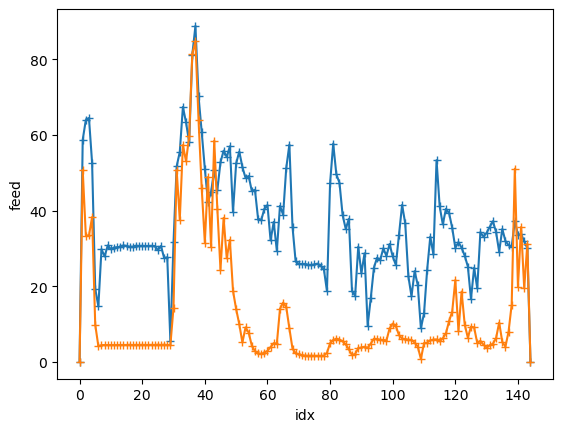

In [54]:
display(df_offline_cc.head())
display(df_offline_cc.tail())

plt.plot(df_offline_cc["feed_curve"], marker = "+")
plt.plot(df_no_cc["feed_curve"], marker = "+")
plt.xlabel("idx")
plt.ylabel("feed")
plt.show()


In [118]:
MILLING_PATH_CSV = Path.cwd().parents[1] / "data" / "paths" / "Workpiece_long_with_start_milling_path.csv"
path_pd = pd.read_csv(MILLING_PATH_CSV)
display(path_pd.head())

,Unnamed: 0,x,y
0,0,5.000000,-190.000000
1,1,4.929070,-184.435810
2,2,4.887914,-179.567822
3,3,4.871276,-175.265310
4,4,4.873903,-171.397547


In [114]:
import numpy as np
from shapely import LineString, Point
from scipy.interpolate import make_interp_spline

class MillingPath():
    def __init__(self, path_coordinates: np.ndarray | LineString, axial_cutting_dept: float=5.0, feed_curve: np.ndarray | float=40.0, offset: float=None, offset_side: str='left'):
        if isinstance(path_coordinates, LineString):
            self.path_ls = path_coordinates
        else:
            self.path_ls = LineString(path_coordinates)
        
        if not offset is None:
            self.path_ls = self.path_ls.parallel_offset(distance=offset, side=offset_side)

        support_points, distances = self.n_support_points()
        self.spline_x = make_interp_spline(distances, support_points[:, 0], k=5) # C4 continuous
        self.spline_y = make_interp_spline(distances, support_points[:, 1], k=5)

        self.feed_curve = feed_curve    # in [mm/s]
        if isinstance(feed_curve, np.ndarray):
            self.feed_curve = make_interp_spline(feed_curve[:, 0], feed_curve[:, 1], k=3)
            # self.feed_curve = Akima1DInterpolator(feed_curve[:, 0], feed_curve[:, 1], method="makima")

        self.axial_cutting_depth = axial_cutting_dept

    def length(self) -> float:
        """Return length of milling path."""
        return self.path_ls.length
    
    def points_at_distances(self, distances: np.ndarray) -> np.ndarray:
        """Return coordinates of point at a certain distance on milling path."""
        distances[distances > self.length()] = self.length()
        x_spline = self.spline_x(distances)
        y_spline = self.spline_y(distances)

        return np.array([x_spline, y_spline])
    
    def feed_at_distances(self, distances: np.ndarray) -> np.ndarray:
        """Return the planned feedrate at a certain distance on milling path."""
        distances[distances > self.length()] = self.length()
        if isinstance(self.feed_curve, float):
            feed_speed = np.ones(len(distances)) * self.feed_curve
        else:
            feed_speed = self.feed_curve(distances)

        return feed_speed

    def support_points_distances(self) -> np.ndarray:
        """Return the positions of the support points along the milling path."""
        coords = np.array(self.path_ls.coords)
        diffs = np.diff(coords, axis=0)
        segment_distances = np.linalg.norm(diffs, axis=1)
        cumulative_distances = np.insert(np.cumsum(segment_distances), 0, 0)

        return cumulative_distances
    
    def n_support_points(self, n_points: int=np.inf):
        """Pick out fraction of support points."""
        coords = np.array(self.path_ls.coords)
        distances_all = self.support_points_distances()

        n = len(coords)

        if n_points >= n:
            picked_points = [Point(x, y) for x, y in coords]
            distances = list(distances_all)
        else:
            selected_indices = np.linspace(0, n - 1, n_points).astype(int)
            picked_points = [Point(coords[i]) for i in selected_indices]
            distances = [distances_all[i] for i in selected_indices]
    
        return  np.array([np.array(d.coords[0]) for d in picked_points]), np.array(distances)
        

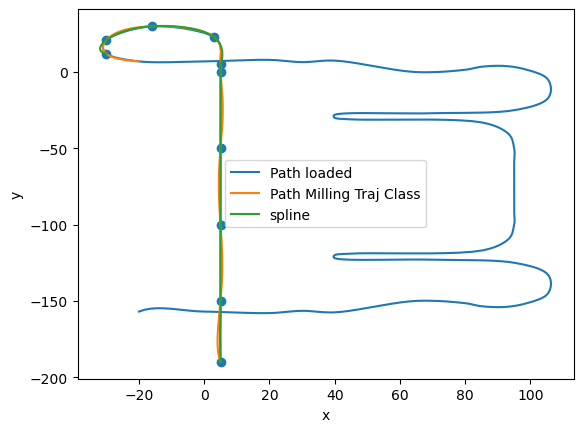

In [117]:

from scipy.interpolate import make_interp_spline

def planned_waypoints_full_with_start(x_offset_mm: float = 0.0, y_offset_mm: float = 0.0) -> np.ndarray:
    WORKPIECE_WIDTH_Y_MM = 150.0
    path_coordinates = np.array(
        [
            [-20.0, 7.0],
            [0.0, 7.0],
            [20.0, 8.0],
            [30.0, 6.5],
            [40.0, 7.5],
            [65.0, 0.0],
            [80.0, 1.5],
            [85.0, 3.5],
            [92.0, 4.0],
            [98.0, 2.0],
            [105.0, -4.0],
            [105.0, -18.0],
            [95.0, -25.0],
            [70.0, -27.0],
            [40.0, -28.0],
            [40.0, -30.0],
            [45.0, -31.0],
            [85.0, -33.0],
            [93.0, -40.0],
            [95.0, -50.0],
            [95.0, -60.0],
        ],
        dtype=float,
    )
    path_start_coordinates = np.array(
        [
            [5.0, -190.0],
            [5.0, -150.0],
            [5.0, -100.0],
            [5.0, -50.0],
            [5.0, 0.0],
            [5.0, 5.0],
            [3.0, 23.0],
            [-16.0, 30.0],
            [-30.0, 21.0],
            [-30.0, 12.0],
        ],
        dtype=float,
    )

    mirrored = np.array([1.0, -1.0]) * np.flip(path_coordinates, axis=0) - np.array([0.0, WORKPIECE_WIDTH_Y_MM])
    waypoints = np.concatenate([path_start_coordinates, path_coordinates, mirrored], axis=0)
    # waypoints = np.concatenate(path_start_coordinates , path_coordinates, )
    waypoints[:, 0] += float(x_offset_mm)
    waypoints[:, 1] += float(y_offset_mm)
    return waypoints

waypoints = planned_waypoints_full_with_start()
idx_max = 10
waypoints_reduced = waypoints[:idx_max , :]



s = np.arange(len(waypoints_reduced))
spline = make_interp_spline(s, waypoints_reduced, k=3)

t_fine = np.linspace(s[0], s[-1], 500)
curve = spline(t_fine)


milling_path = MillingPath(waypoints)
distance_segments = milling_path.support_points_distances()
s_end = distance_segments[idx_max]
s = np.linspace(0, s_end, 300)
points = milling_path.points_at_distances(s)
x = points[0]
y = points[1]

plt.plot(path_pd["x"], path_pd["y"], label = "Path loaded")
plt.plot(x, y, label = "Path Milling Traj Class")
plt.xlabel("x")
plt.ylabel("y")
# plt.scatter(waypoints[:,0], waypoints[:,1])
plt.scatter(waypoints_reduced[:,0], waypoints_reduced[:,1])
plt.plot(curve[:, 0], curve[:, 1], "-", label="spline")
plt.legend()
plt.show()



In [ ]:
distance_segments = milling_path.support_points_distances()[:idx_max + 1]
s_0 = distance_segments[idx_max]

df_traj = df_offline_cc[df_offline_cc["x_support"] <= s_0].copy()
display(df_traj.head())
display(df_traj.tail())

,x_support,feed_curve
0,0.000000,0.000000
1,6.138636,58.741607
2,12.277273,63.997457
3,18.415909,64.503690
4,24.554546,52.628437


,x_support,feed_curve
40,245.545458,51.121004
41,251.684095,42.328593
42,257.822731,44.975502
43,263.961368,50.777351
44,270.100004,45.520108


In [119]:
display(df_offline_cc.head())

points = milling_path.points_at_distances(df_offline_cc["x_support"])
x = points[0]
y = points[1]

plt.plot(x - path_pd["x"])
plt.xlabel("idx")
plt.ylabel("x")
plt.show()

,x_support,feed_curve
0,0.000000,0.000000
1,6.138636,58.741607
2,12.277273,63.997457
3,18.415909,64.503690
4,24.554546,52.628437


ValueError: operands could not be broadcast together with shapes (145,) (511,) 